# Playing around with editing the LiveOcean boundary conditions at JdF

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cm
import pandas as pd
import gsw
from salishsea_tools.LiveOcean_BCs import convect, stabilize

In [2]:
day1 = xr.open_dataset('/results/forcing/LiveOcean/boundary_conditions/LiveOcean_v201905_y2018m01d01.nc')
day1

# the way nemo needs the boundary conditions is as a 2D array even though it is actually 10 rows of boundary conditions
# SO what we have is the depth array (40) followed by a 950 length X array
# this is just 10 length 95 arrays stuck one after another

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 1, deptht: 40, yb: 1, xbT: 950)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2018-01-01T12:00:00
  * deptht        (deptht) float64 320B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * yb            (yb) int64 8B 1
  * xbT           (xbT) int64 8kB 0 1 2 3 4 5 6 ... 943 944 945 946 947 948 949
Data variables:
    vosaline      (time_counter, deptht, yb, xbT) float64 304kB ...
    votemper      (time_counter, deptht, yb, xbT) float64 304kB ...
    NO3           (time_counter, deptht, yb, xbT) float64 304kB ...
    Si            (time_counter, deptht, yb, xbT) float64 304kB ...
    OXY           (time_counter, deptht, yb, xbT) float64 304kB ...
    DIC           (time_counter, deptht, yb, xbT) float64 304kB ...
    TA            (time_counter, deptht, yb, xbT) float64 304kB ...
Attributes:
    acknowledgements:      Live Ocean http://faculty.washington.edu/pmacc/LO/...
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    summary:               Temperature, Salinity, Nitrate, Oxygen, DIC and TA...
    source:                http://nbviewer.jupyter.org/urls/bitbucket.org/sal...
    history:               [2019-06-10] File creation.

In [3]:
# build an easily editable tracer dictionary 
original_interps = {
    "salt":       day1["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       day1["votemper"][0, :, :, :].values.copy(),
    "NO3":        day1["NO3"][0, :, :, :].values.copy(),
    "Si":         day1["Si"][0, :, :, :].values.copy(),
    "oxygen":     day1["OXY"][0, :, :, :].values.copy(),
    "TIC":        day1["DIC"][0, :, :, :].values.copy(),
    "alkalinity": day1["TA"][0, :, :, :].values.copy(),
}

interps = {k: v.copy() for k, v in original_interps.items()}

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

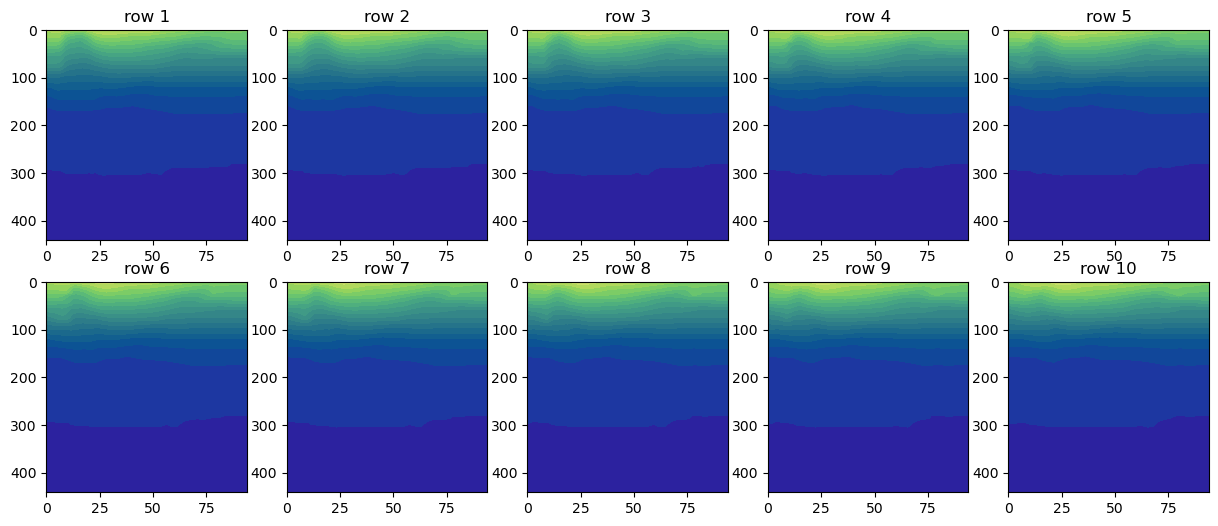

In [4]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = original_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

In [ ]:
# bring in water mass fraction data
floop = pd.read_csv('./output/inflowfraction_D_loop.csv').drop(columns=['Unnamed: 0'])
ffresh = pd.read_csv('./output/inflowfraction_D_fresh.csv').drop(columns=['Unnamed: 0'])
fsouth = pd.read_csv('./output/inflowfraction_D_south.csv').drop(columns=['Unnamed: 0'])
fcuc = pd.read_csv('./output/inflowfraction_D_cuc.csv').drop(columns=['Unnamed: 0'])
foffD = pd.read_csv('./output/inflowfraction_D_offD.csv').drop(columns=['Unnamed: 0'])
foffS = pd.read_csv('./output/inflowfraction_D_offS.csv').drop(columns=['Unnamed: 0'])
fnorth = pd.read_csv('./output/inflowfraction_D_north.csv').drop(columns=['Unnamed: 0'])

In [6]:
# get depth fraction profile of a certain water mass on a specific day 
def get_depth_profile(df, date_str):
    row = df.loc[df["day"] == date_str]
    prof = row.select_dtypes(include=np.number).to_numpy().squeeze()
    return prof  # shape (40,)

In [7]:
# lets hypothetically say that we think the salinity of south water and the CUC are gonna increase by 0.2 g/kg
# and that the salinity of offS water will decrease by 0.3 g/kg

date_str = '2018-01-01'
south_prof = get_depth_profile(fsouth, date_str)
cuc_prof   = get_depth_profile(fcuc, date_str)
offS_prof  = get_depth_profile(foffS, date_str)

# edit salinity, keep same 3-D array shape (depth, yb, xbT)
for k in range(interps["salt"].shape[0]):
    delta_s = (
        south_prof[k] * 0.2
        + cuc_prof[k] * 0.2
        - offS_prof[k] * 0.3
    )
    interps["salt"][k, :, :] += delta_s


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

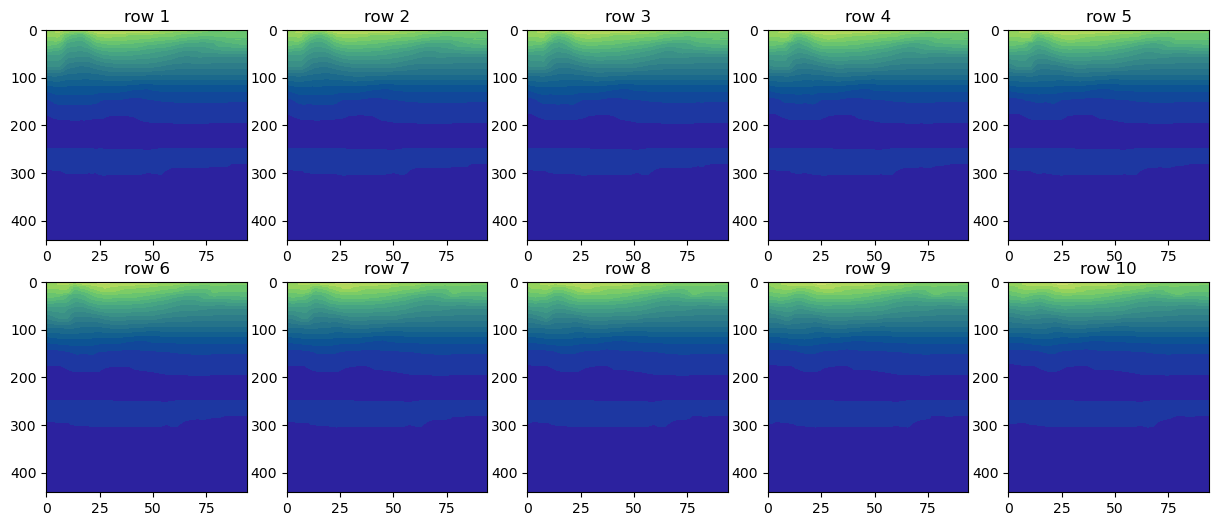

In [8]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

# you can see here that there would be an instability introduced, look into code for checking and fixing instabilities next

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

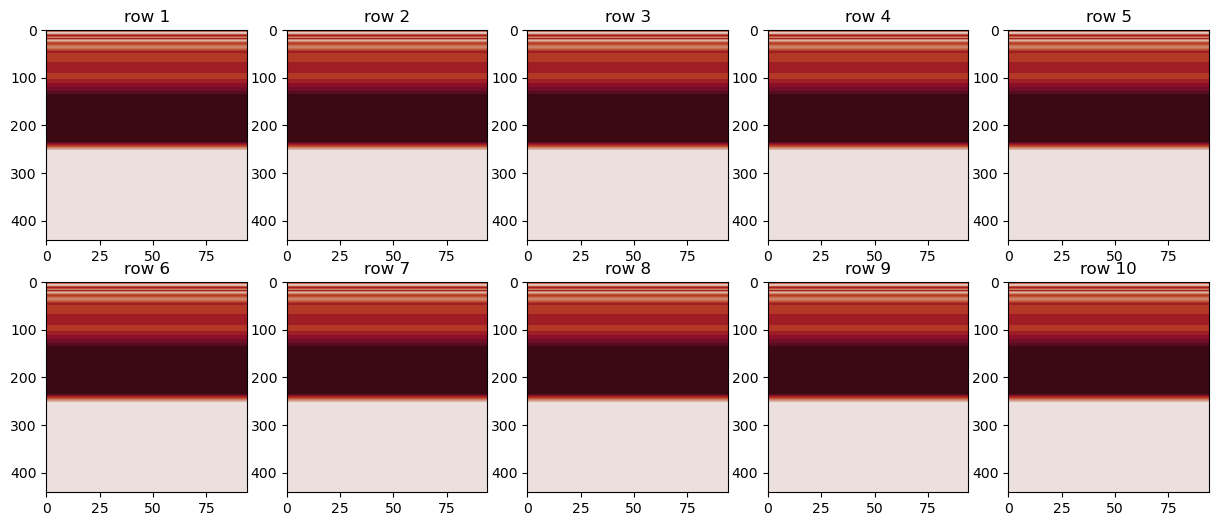

In [9]:
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)] - original_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.balance,vmin=-0.1,vmax=0.1)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

## stabilize
adding salinity like we did made it such that the water ~280 m is lighter than the water above it - uh oh! <br>
let's try to bring in some of stabilization functions that Susan has for the actual making of the BC files here <br>

In [10]:
# start by applying convect
# this function simply convects vertically based on the density of cells on top of eachother
sigma = gsw.sigma0(interps['salt'], interps['temp']) # need density first
sigma, interps = convect(sigma, interps)

# stabilize (small changes to salinity to stabilize marginally stable cells)
interps = stabilize(sigma, interps)

In [11]:
# diagnostic: minimum density difference between adjacent levels
dsig = np.diff(sigma, axis=0)
print("Minimum sigma0 difference after stabilize:", np.nanmin(dsig)) # if negative then something wrong

Minimum sigma0 difference after stabilize: 0.0


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

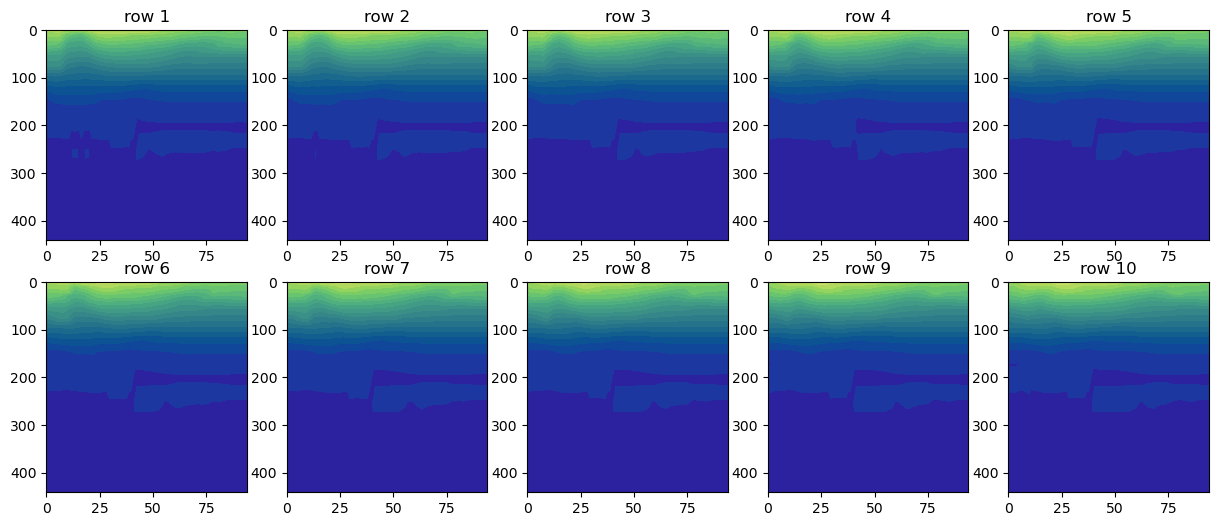

In [12]:
vmin, vmax = 30,34.5
X, Y = np.meshgrid(day1.xbT[0:95].values,day1.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout

## get it back into a netcdf file

In [13]:
out = day1.copy(deep=True)

out["vosaline"][0, :, :, :] = interps["salt"]
out["votemper"][0, :, :, :] = interps["temp"]
out["NO3"][0, :, :, :]      = interps["NO3"]
out["Si"][0, :, :, :]       = interps["Si"]
out["OXY"][0, :, :, :]      = interps["oxygen"]
out["DIC"][0, :, :, :]      = interps["TIC"]
out["TA"][0, :, :, :]       = interps["alkalinity"]

# update metadata
out.attrs["history"] = out.attrs.get("history", "") + " | edited for 2100 under SSP 8.5"

# save!
out.to_netcdf("./LiveOcean_v201905_y2018m01d01_modified.nc")#, encoding=encoding)

In [ ]:
test = xr.open_dataset('/ocean/rbeutel/MOAD/analysis-becca/projections/output/LiveOcean_v201905_y2018m01d01_modified.nc')
test

<xarray.Dataset> Size: 2MB
Dimensions:       (time_counter: 1, deptht: 40, yb: 1, xbT: 950)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 8B 2018-01-01T12:00:00
  * deptht        (deptht) float64 320B 0.5 1.5 2.5 3.5 ... 387.6 414.5 441.5
  * yb            (yb) int64 8B 1
  * xbT           (xbT) int64 8kB 0 1 2 3 4 5 6 ... 943 944 945 946 947 948 949
Data variables:
    vosaline      (time_counter, deptht, yb, xbT) float64 304kB ...
    votemper      (time_counter, deptht, yb, xbT) float64 304kB ...
    NO3           (time_counter, deptht, yb, xbT) float64 304kB ...
    Si            (time_counter, deptht, yb, xbT) float64 304kB ...
    OXY           (time_counter, deptht, yb, xbT) float64 304kB ...
    DIC           (time_counter, deptht, yb, xbT) float64 304kB ...
    TA            (time_counter, deptht, yb, xbT) float64 304kB ...
Attributes:
    acknowledgements:      Live Ocean http://faculty.washington.edu/pmacc/LO/...
    creator_email:         sallen@eoas.ubc.ca
    creator_name:          Salish Sea MEOPAR Project Contributors
    creator_url:           https://salishsea-meopar-docs.readthedocs.org/
    institution:           UBC EOAS
    institution_fullname:  Earth, Ocean & Atmospheric Sciences, University of...
    summary:               Temperature, Salinity, Nitrate, Oxygen, DIC and TA...
    source:                http://nbviewer.jupyter.org/urls/bitbucket.org/sal...
    history:               [2019-06-10] File creation. | edited for 2100 unde...

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

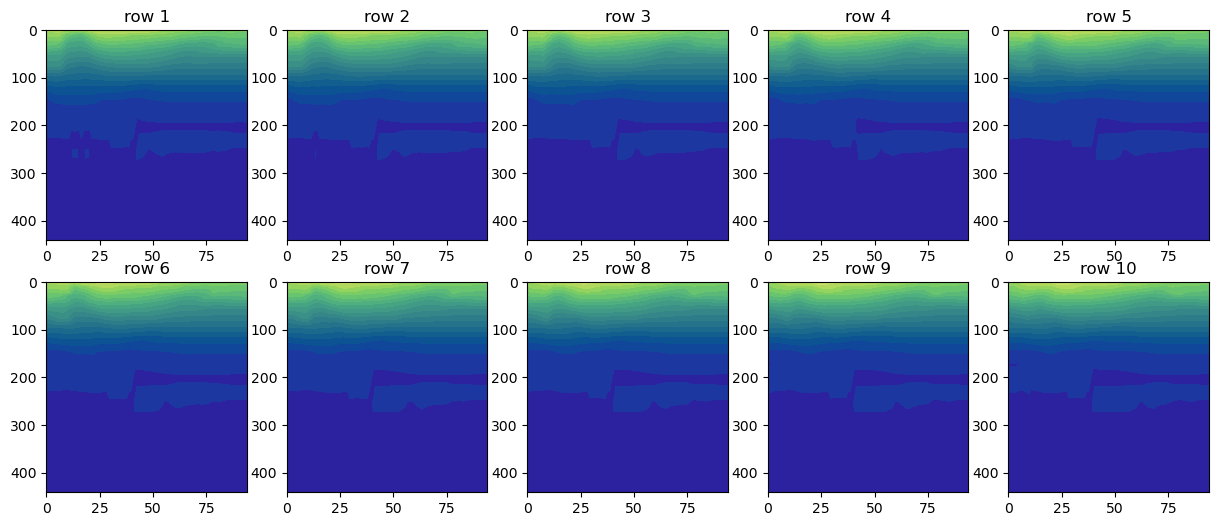

In [15]:
# build an easily editable tracer dictionary 
test_interps = {
    "salt":       test["vosaline"][0, :, :, :].values.copy(),   # (40, 1, 950)
    "temp":       test["votemper"][0, :, :, :].values.copy(),
    "NO3":        test["NO3"][0, :, :, :].values.copy(),
    "Si":         test["Si"][0, :, :, :].values.copy(),
    "oxygen":     test["OXY"][0, :, :, :].values.copy(),
    "TIC":        test["DIC"][0, :, :, :].values.copy(),
    "alkalinity": test["TA"][0, :, :, :].values.copy(),
}

vmin, vmax = 30,34.5
X, Y = np.meshgrid(test.xbT[0:95].values,test.deptht.values)

fig, ax = plt.subplots(2,5,figsize=[15,6])

for i in range(10):

    if i <5:
        row = 0
        column = i
    else:
        row = 1
        column = i-5

    title=f"row {i+1}"
    ax[row,column].set_title(title)
    sal = test_interps['salt'][:,0,95*i:95*(i+1)]
    cs = ax[row,column].contourf(X,Y,sal,levels=20,cmap=cm.haline_r,vmin=30,vmax=34.5)
    ax[row,column].set_ylim([np.max(Y),0])

plt.tight_layout